#### Model Training

1.1 Import Data and Required Packages

##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modelling 
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Import the CSV as pandas Dataframe

In [3]:
df = pd.read_csv("data/raw.csv")

### show top 5 records

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Prepare X and Y variables

In [ ]:
X = df.drop(columns=["math_score"])

In [9]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [18]:
print("Categories in 'gender' variable:     ",end=" " )
print(df["gender"].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [22]:
y = df["math_score"]

In [23]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math_score, dtype: int64

In [37]:
# Create column tranformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_tranformer = StandardScaler()
oh_tranformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder",oh_tranformer, cat_features),
        ("StandardScaler",numeric_tranformer, num_features),
    ]
)


C:\Users\Admin\AppData\Local\Temp\ipykernel_18268\1901974233.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [38]:
X = preprocessor.fit_transform(X)

In [40]:
X.shape

(1002, 19)

In [47]:
# Separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((801, 19), (201, 19))

# Create an evaluate function to give all metrics after model training


In [48]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true,predicted)
    mse = mean_squared_error(true,predicted)
    rmse = np.sqrt(mean_squared_error(true,predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [50]:
models ={
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "k-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "Adaboost Regressor": AdaBoostRegressor()

}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 =evaluate_model(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')
    


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.3662
- Mean Absolute Error: 4.0442
- R2 Score: 0.8956


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.6361
- Mean Absolute Error: 4.7700
- R2 Score: 0.8527


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.3665
- Mean Absolute Error: 4.0312
- R2 Score: 0.8962


k-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.8218
- Mean Absolute Error: 5.1413
- R2 Score: 0.8176


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.4298
- Mean Absolute Error: 6.6169
- R2 Score: 0.7259


Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 2.3686
- Mean Absolute Error: 4.5544
- R2 Score: 0.8613


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 1.0214
- Mean Absolute Error: 5.2428
- R2 Score: 0.8280


CatBoosting Regressor
Model performance for Training set


# Result

In [52]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name','R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.896169
0,Linear Regression,0.895591
5,Random Forest Regressor,0.865684
7,CatBoosting Regressor,0.857115
1,Lasso,0.852732
8,AdaBoost Regressor,0.848283
6,XGBRegressor,0.827959
3,K-Neighbors Regressor,0.817641
4,Decision Tree,0.723104


# Linear Regression

In [53]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is % 2f" %score)

 Accuracy of the model is  89.559058


# Plot y_pred and y_test

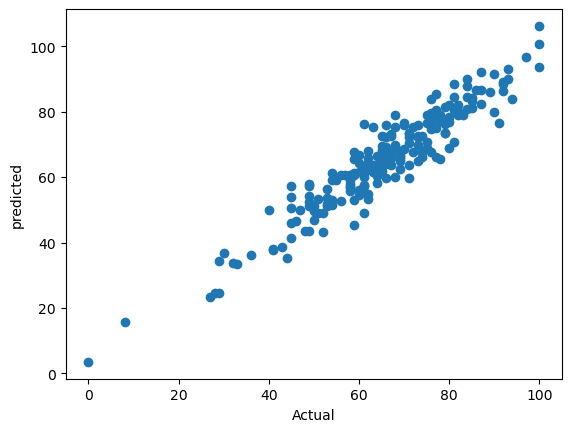

In [54]:
plt.scatter(y_test, y_pred);
plt.xlabel('Actual');
plt.ylabel('predicted');

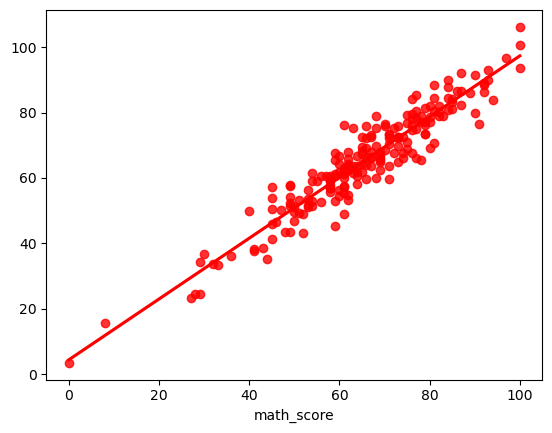

In [56]:
sns.regplot(x=y_test, y=y_pred, ci=None, color ='red');

#### Difference between Actual and Predicted Values

In [57]:
pred_df = pd.DataFrame({'Actual Value':y_test, 'predicted_Value':y_pred, 'Difference':y_test-y_pred})
pred_df

,Actual Value,predicted_Value,Difference
521,91,76.454248,14.545752
739,61,60.029859,0.970141
823,71,73.541705,-2.541705
662,55,59.144785,-4.144785
411,84,87.765210,-3.765210
...,...,...,...
332,62,62.432997,-0.432997
208,74,67.679328,6.320672
615,60,64.327035,-4.327035
78,61,62.081393,-1.081393
